## ARTIFICIAL NEURAL NETWORKS

#### 1. Data Exploration & Preprocessing

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv(r'C:\Users\suraj\OneDrive\Desktop\data sets\Alphabets_data.csv')

# Basic info
print(df.shape)
print(df.head())
print(df.info())
print(df['letter'].value_counts())   # target column (usually 'letter')

# Check missing values
print(df.isnull().sum())

(20000, 17)
  letter  xbox  ybox  width  height  onpix  xbar  ybar  x2bar  y2bar  xybar  \
0      T     2     8      3       5      1     8    13      0      6      6   
1      I     5    12      3       7      2    10     5      5      4     13   
2      D     4    11      6       8      6    10     6      2      6     10   
3      N     7    11      6       6      3     5     9      4      6      4   
4      G     2     1      3       1      1     8     6      6      6      6   

   x2ybar  xy2bar  xedge  xedgey  yedge  yedgex  
0      10       8      0       8      0       8  
1       3       9      2       8      4      10  
2       3       7      3       7      3       9  
3       4      10      6      10      2       8  
4       5       9      1       7      5      10  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   letter  20000 non-null  obj

Preprocessing

In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Encode target (A–Z → 0–25)
le = LabelEncoder()
y = le.fit_transform(df['letter'])

# Features
X = df.drop('letter', axis=1)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

#### 2. ANN Model Implementation

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build ANN model
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(26, activation='softmax'))  # 26 classes (A–Z)

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

C:\Users\suraj\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4369 - loss: 2.0190 - val_accuracy: 0.6700 - val_loss: 1.1447
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7227 - loss: 0.9673 - val_accuracy: 0.7688 - val_loss: 0.8349
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7812 - loss: 0.7628 - val_accuracy: 0.8041 - val_loss: 0.6995
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8137 - loss: 0.6454 - val_accuracy: 0.8297 - val_loss: 0.6112
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8355 - loss: 0.5606 - val_accuracy: 0.8375 - val_loss: 0.5456
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8566 - loss: 0.4972 - val_accuracy: 0.8581 - val_loss: 0.4931
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8717 - loss: 0.4450 - val_accuracy: 0.8678 - val_loss: 0.4504
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8812 - loss: 0.4061 - val_accuracy: 0.

#### 3. Evaluation

In [4]:
from sklearn.metrics import classification_report

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Accuracy
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

# Classification report
print(classification_report(y_test, y_pred_classes))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9227 - loss: 0.2496
Test Accuracy: 0.9227499961853027
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       158
           1       0.84      0.86      0.85       153
           2       0.96      0.95      0.96       147
           3       0.90      0.93      0.91       161
           4       0.88      0.90      0.89       154
           5       0.92      0.91      0.92       155
           6       0.88      0.92      0.90       155
           7       0.83      0.86      0.84       147
           8       0.95      0.93      0.94       151
           9       0.97      0.93      0.95       149
          10       0.93      0.93      0.93       148
          11       0.91      0.95      0.93       152
          12       0.98      0.94      0.96       158
          13       0.93      0.92      0.93       157
          14       0.96      0.89      

#### 4. Hyperparameter Tuning

In [5]:
model = Sequential()
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(26, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=30, batch_size=16)

Epoch 1/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6590 - loss: 1.2209
Epoch 2/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8349 - loss: 0.5609
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8816 - loss: 0.4040
Epoch 4/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9022 - loss: 0.3219
Epoch 5/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9219 - loss: 0.2614
Epoch 6/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9317 - loss: 0.2231
Epoch 7/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9408 - loss: 0.1960
Epoch 8/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9480 - loss: 0.1700
Epoch 9/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9504 - loss: 0.1528
Epoch 10/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9563 - loss: 0.1391
Epoch 11/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9587 - loss: 0.1299
Epoch 12/30
1000/1000 ━━━━━━━━

Grid Search (Structured Tuning)

In [6]:
!pip install scikeras

In [7]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

def create_model(neurons=32):
    model = Sequential()
    model.add(Dense(neurons, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(26, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = KerasClassifier(model=create_model, verbose=0)

param_grid = {
    'model__neurons': [32, 64, 128],
    'batch_size': [16, 32],
    'epochs': [10, 20]
}

grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3)
grid_result = grid.fit(X_train, y_train)

print("Best Params:", grid_result.best_params_)
print("Best Score:", grid_result.best_score_)

C:\Users\suraj\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\suraj\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\suraj\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwa

Best Params: {'batch_size': 16, 'epochs': 20, 'model__neurons': 128}
Best Score: 0.9283126244321654


In [10]:
from keras.models import Sequential
from keras.layers import Dense, Input

model = Sequential()

# Use Input layer first
model.add(Input(shape=(10,)))  

model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

#### 5. Visualization (Training Performance)

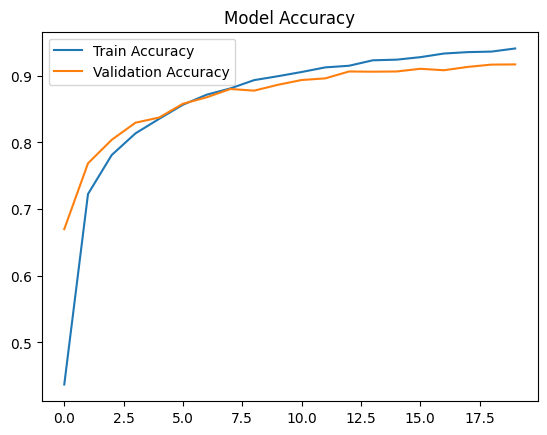

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

#### 6. Final Discussion 


Before Tuning:
Moderate accuracy
Possible underfitting 
After Tuning:
Improved accuracy
Better generalization
Optimal neuron/layer combination
Key Observations:
More neurons → better learning (but risk of overfitting)
Learning rate affects convergence
Batch size impacts training speed